### **Code: 바이오소재 본설문 분석**
#### Writer : Donghyeon Kim
#### Update : 2025.10.29.

---

#### **0. Prior Settings**

In [1]:
# Library
from pathlib import Path
from matplotlib import font_manager
from numpy.linalg import LinAlgError
from statsmodels.tools.sm_exceptions import PerfectSeparationError, ConvergenceWarning, HessianInversionWarning
from scipy.stats import chi2, norm
from scipy import stats
from statsmodels.tools import add_constant
from statsmodels.tools.numdiff import approx_fprime, approx_hess
import os
import sys
import pandas as pd
import numpy as np
import re
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Python Options
pd.set_option("display.max_columns", 600)

# Utils : 본설문 WTP 반복 분석 로직
module_dir = Path.cwd()
if not (module_dir / "wtp_analysis_utils.py").exists() and (module_dir / "2. Python Code" / "wtp_analysis_utils.py").exists():
    module_dir = module_dir / "2. Python Code"
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from wtp_analysis_utils import (
    estimate_wtp_bid_only,
    estimate_wtp_selected_covariates,
    run_first_stage_logit,
    run_second_stage_logit,
)

In [2]:
# 프로젝트 기준 경로 설정
folder_root = Path(os.getcwd())
root = folder_root.parent

##### Data : 본설문 Rawdata
* 수집 Tool : 모아폼
* 특이사항 : 직접 취합 진행 완료

In [3]:
# 본설문 원자료 불러오기
data_path = os.path.join(root, '1. Rawdata', '2. 본설문')

# Data 파일명
data_file_name = os.path.join(data_path, '본설문_Rawdata_통합_분석용.xlsx')
data_file_sheet = 'Responses'

# Data 호출
df = pd.read_excel(data_file_name, sheet_name=data_file_sheet)

In [4]:
# 분석 결과 저장 경로
result_path = os.path.join(root, '3. Result', '2. 본설문', 'Extracts')

##### 한글 Font 설정

In [5]:
# 한글 그래프 표시 설정(Mac 기본 폰트)
# Font : Apple SD Gothic Neo
mpl.rcParams["font.family"] = "Apple SD Gothic Neo"
mpl.rcParams["axes.unicode_minus"] = False
# seaborn에서도 동일하게 적용
sns.set_theme(style="white", rc={"font.family": "Apple SD Gothic Neo", "axes.unicode_minus": False})
print("폰트 설정: Apple SD Gothic Neo")

#####################
# # Windows : 폰트 설정
# # Font : Malgun Gothic (맑은 고딕)
# mpl.rcParams["font.family"] = "Malgun Gothic"
# mpl.rcParams["axes.unicode_minus"] = False
# # seaborn에서도 동일하게 적용
# sns.set_theme(style="white", rc={"font.family": "Malgun Gothic", "axes.unicode_minus": False})
# print(mpl.rcParams["font.family"])

폰트 설정: Apple SD Gothic Neo


---

#### **Part 1. 기술분석**

#### 1) 인구통계학적 통계

In [6]:
# 인구통계 문항별 빈도표와 막대그래프 저장
col_map = {
    "성별": "P1-Q1",
    "나이": "P1-Q2",
    "소속기관": "P1-Q3",
    "직급": "P1-Q4",
    "최종학력": "P1-Q5",
    "과제책임여부": "P1-Q6",
    "전공": "P1-Q7",
}

missing = [label for label, col in col_map.items() if col not in df.columns]
if missing:
    print("다음 항목은 지정한 컬럼이 데이터에 없음: ", missing)

MISSING_TEXT = {"무응답", "미응답", "없음", "해당없음", "해당 없음", "N/A", "NA", "na", "NaN", "None", ""}
TEXT_REPLACEMENTS = [
    # 공통 표기 정리
    (" (출연(연), 국공립(연) 등)", ""),
    # 직급: 자유응답으로 들어온 유사 직급명을 대표값으로 통합
    ("박사 과정", "박사과정"),
    ("박사과정생", "박사과정"),
    ("석사과정생", "석사과정"),
    ("선임", "선임연구원"),
    ("전임", "전임연구원"),
    ("학생", "학사연구원"),
    ("학생연구원", "학사연구원"),
    ("부교수", "교수"),
    ("조교수", "교수"),
    ("학술연구교수", "교수"),
    ("박사후 과정", "박사후과정"),
    ("박사후 연구원", "박사후연구원"),
    ("박사과정 수료생", "박사과정"),
    ("선임연구원기술원", "선임연구원"),
    ("선임연구원연구기사", "선임연구원"),
    ("선임연구원연구원", "선임연구원"),
    ("전임연구원연구원", "전임연구원"),
    ("책임", "책임연구원"),
    ("책임급연구원", "책임연구원"),
    ("책임연구원연구원", "책임연구원"),
    ("책임연구원급연구원", "책임연구원"),
    ("책임연구원연구기사", "책임연구원"),
    ("학사연구원연구원", "학사연구원"),
    ("YS포닥", "포닥"),
    ("연구관", "연구원"),
    ("연구기사", "연구원"),
    ("계약직연구원", "연구원"),
    # 과제책임여부: 기타 응답을 분석용 범주로 통합
    ("과제책임연구원자", "과제책임자"),
    ("기타: 과제관리자", "과제책임자"),
    ("기타: 대학원생", "기타(대학원생)"),
    ("기타: 실무자", "공동연구원"),
    ("기타: 연구참여자", "공동연구원"),
    ("기타: 참여연구원", "공동연구원"),
    ("기타: 연구원", "공동연구원"),
    ("기타: 협력업체", "기타(협력업체)"),
    ("기타: 과제 수행하고 있지 않음", "기타(현 과제 미진행)"),
    # 전공: 세부 기타 응답은 보고서용 대분류 '기타'로 묶음
    ("기타: AI기반 신약설계", "기타"),
    ("기타: 생명공학", "기타"),
    ("기타: 생약학", "기타"),
    ("기타: 수의예방학", "기타"),
    ("기타: 수의학", "기타"),
    ("기타: 식품영양학", "기타"),
    ("기타: 종양생물학", "기타"),
    ("기타: 천연물화학", "기타"),
    ("기타: 컴퓨터 사이언스", "기타"),
    ("기타: 컴퓨터공학", "기타"),
    ("기타: 화공생명공학", "기타"),
    ("기타: 화학", "기타"),
    ("기타: 환경공학", "기타"),
]

def clean_text(x):
    """무응답은 결측으로 두고, 같은 의미의 자유응답 표기를 하나의 분석 범주로 맞춤"""
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    if s in MISSING_TEXT:
        return np.nan

    for old, new in TEXT_REPLACEMENTS:
        s = s.replace(old, new)
    return s

def freq_table(series: pd.Series) -> pd.DataFrame:
    """문항 응답을 정리한 뒤 빈도와 비율을 계산한다."""
    cleaned = series.map(clean_text).dropna()
    counts = cleaned.value_counts()
    perc = (counts / counts.sum() * 100).round(1)
    return (
        pd.DataFrame({"항목": counts.index.astype(str), "빈도": counts.values, "비율(%)": perc.values})
        .sort_values("항목")
        .reset_index(drop=True)
    )

for label, col in col_map.items():
    if col not in df.columns:
        continue

    tbl = freq_table(df[col])
    tbl.to_csv(os.path.join(result_path, f"{label}_빈도표.csv"), index=False, encoding="utf-8-sig")

    plt.figure(figsize=(8, 5))
    x = np.arange(len(tbl))
    plt.bar(x, tbl["빈도"].values)
    plt.xticks(x, tbl["항목"].values, rotation=30, ha="right")
    plt.ylabel("빈도")
    plt.title(f"{label} 분포 (n={int(tbl['빈도'].sum())})")
    plt.tight_layout()
    plt.savefig(os.path.join(result_path, f"{label}_bar.png"), dpi=300)
    plt.close()

#### 2) 지불의사금액 (개방형 질문 응답)

In [7]:
# 1) 숫자 : 콤마/공백/'원' 허용
def to_number(x):
    if pd.isna(x): 
        return np.nan
    s = str(x).strip()
    if s == "":
        return np.nan
    s = re.sub(r"[,\s원]", "", s)
    try:
        return float(s)
    except:
        return np.nan


# 2) 분석 대상 문항 : (예, 예) / (예, 아니오) / (아니오, 예) / (아니오, 아니오)
target_cols = ["P4-Q3", "P4-Q4", "P4-Q6", "P4-Q7"]

# 숫자형 변환
for col in target_cols:
    if col in df.columns:
        df[col] = df[col].map(to_number)

# 3) Info1 + Info2 조합 요약
rows = []
for (info1, info2), sub in df.groupby(["Info1", "Info2"], dropna=False):
    vals = sub[target_cols].to_numpy().ravel()
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        mean_val, fivenum, cnt = np.nan, [np.nan]*5, 0
    else:
        mean_val = float(np.mean(vals))
        fivenum  = np.percentile(vals, [0,25,50,75,100]).astype(float)
        cnt = int(len(vals))
    rows.append({
        "Info1": info1,
        "Info2": info2,
        "Mean": round(mean_val, 2) if not np.isnan(mean_val) else np.nan,
        "Min": fivenum[0], "Q1": fivenum[1], "Median(Q2)": fivenum[2],
        "Q3": fivenum[3], "Max": fivenum[4], "Count": cnt
    })

summary = pd.DataFrame(rows)


# 4) Info1 내에서 Info2를 120,000 → 360,000 → 600,000 → 840,000 → 1,200,000 순으로 정렬
bid_order = [120000, 360000, 600000, 840000, 1200000]

def bid_rank(x):
    xnum = to_number(x)
    if np.isnan(xnum):
        return 999  # 결측/이상치는 뒤로
    try:
        return bid_order.index(int(xnum))  # 사전 정의 순서
    except ValueError:
        # 정의 밖 값은 숫자 크기 기준으로 뒤쪽에 정렬
        return 500 + int(xnum)

# 임시 정렬 키 컬럼 추가
summary["__Info2_rank__"] = summary["Info2"].map(bid_rank)

# Info1 먼저, 그 다음 __Info2_rank__로 정렬
summary = (summary
           .sort_values(["Info1", "__Info2_rank__", "Info2"], kind="mergesort")
           .drop(columns="__Info2_rank__")
           .reset_index(drop=True))


# 5) 저장
out_path = os.path.join(result_path, "지불의사금액_요약.csv")
summary.to_csv(out_path, index=False, encoding="UTF-8-SIG")
print(f"저장 완료: {out_path}")
summary

저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/지불의사금액_요약.csv


,Info1,Info2,Mean,Min,Q1,Median(Q2),Q3,Max,Count
0,접속자,120000,276500.00,0.0,105000.0,120000.0,165000.0,3000000.0,20
1,접속자,360000,390000.00,30000.0,200000.0,360000.0,450000.0,1000000.0,15
2,접속자,600000,545000.00,100000.0,525000.0,600000.0,700000.0,800000.0,18
3,접속자,840000,1997777.78,350000.0,925000.0,1200000.0,1500000.0,16800000.0,18
4,접속자,1200000,136363.64,100000.0,100000.0,100000.0,100000.0,500000.0,11
5,회원,120000,107857.14,0.0,7500.0,85000.0,142500.0,500000.0,14
6,회원,360000,1580666.67,0.0,110000.0,200000.0,500000.0,20000000.0,15
7,회원,600000,164642.86,0.0,62500.0,200000.0,275000.0,300000.0,14
8,회원,840000,339388.89,10000.0,100000.0,100000.0,480000.0,2400000.0,18
9,회원,1200000,190909.09,0.0,15000.0,120000.0,245000.0,800000.0,11


#### 3) 제시금액(bid 금액)에 대한 응답 분포 (빈도표)

In [8]:
# 제시금액(bid) 응답 분포 집계
# 1차 응답: P4-Q1
# 2차 응답: (1차=예) -> P4-Q2, (1차=아니오) -> P4-Q5
# 그룹: [접속형태, 첫 제시금액]
# 출력 : (1번째) 예/아니오, (2번째) 예/예, 예/아니오, 아니오/예, 아니오/아니오


# 1) 컬럼 이름 탐색
ACCESS_CAND = ["접속형태", "접속방식", "회원구분", "이용형태", "Info1", "Type", "UserType"]
BID1_CAND = ["첫_제시금액", "첫 번째 제시금액", "첫번째 제시금액", "첫 제시금액", "Info2", "P4-BID1"]

def pick_col(cands, cols):
    for c in cands:
        if c in cols: 
            return c
    raise KeyError(f"다음 후보 중 일치하는 컬럼이 없습니다: {cands}")

ACCESS_COL = pick_col(ACCESS_CAND, df.columns)
BID1_COL = pick_col(BID1_CAND, df.columns)


# 2) 값 정규화
# 첫 제시금액 숫자화
def to_number(x):
    if pd.isna(x): return np.nan
    s = re.sub(r"[,\s원]", "", str(x))
    try: return float(s)
    except: return np.nan

df[BID1_COL] = df[BID1_COL].map(to_number)

# 응답 텍스트(예/아니오) 정규화
YN_MAP = {
    "예": "예", "YES": "예", "yes": "예", "Y": "예", "y": "예", "1": "예", "True": "예", "true": "예",
    "아니오": "아니오", "NO": "아니오", "no": "아니오", "N": "아니오", "n": "아니오", "0": "아니오", "False": "아니오", "false": "아니오"
}
for c in ["P4-Q1", "P4-Q2", "P4-Q5"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().map(lambda s: YN_MAP.get(s, s))


# 3) 집계
rows = []
for (acc, bid1), sub in df.groupby([ACCESS_COL, BID1_COL], dropna=False):
    
    # 1차 응답 분포
    first_yes = (sub["P4-Q1"] == "예").sum()
    first_no = (sub["P4-Q1"] == "아니오").sum()
    
    # 1차=예 → 2차는 P4-Q2
    yes_block = sub[sub["P4-Q1"] == "예"]
    yy = (yes_block["P4-Q2"] == "예").sum()         # 예/예
    yn = (yes_block["P4-Q2"] == "아니오").sum()     # 예/아니오
    
    # 1차=아니오 → 2차는 P4-Q5
    no_block = sub[sub["P4-Q1"] == "아니오"]
    ny = (no_block["P4-Q5"] == "예").sum()          # 아니오/예
    nn = (no_block["P4-Q5"] == "아니오").sum()      # 아니오/아니오

    rows.append({
        "접속형태": acc,
        "첫번째 제시금액": bid1,
        "첫번째 응답 - 예": int(first_yes),
        "첫번째 응답 - 아니오": int(first_no),
        "두번째 응답 - 예/예": int(yy),
        "두번째 응답 - 예/아니오": int(yn),
        "두번째 응답 - 아니오/예": int(ny),
        "두번째 응답 - 아니오/아니오": int(nn),
    })

summary = pd.DataFrame(rows)


# 4) 정렬 : (회원 → 접속자, 금액 120,000 → 1,200,000)
acc_order = {"회원": 0, "접속자": 1}
bid_order = [120000, 360000, 600000, 840000, 1200000]

summary["__acc_ord__"] = summary["접속형태"].map(acc_order).fillna(99)
summary["__bid_ord__"] = summary["첫번째 제시금액"].map(
    lambda v: bid_order.index(int(v)) if pd.notna(v) and int(v) in bid_order else 99
)

summary = (summary
           .sort_values(["__acc_ord__", "__bid_ord__"], kind="mergesort")
           .drop(columns=["__acc_ord__", "__bid_ord__"])
           .reset_index(drop=True))


# 5) 저장
out_path = os.path.join(result_path, "제시금액_응답분포.csv")
summary.to_csv(out_path, index=False, encoding="UTF-8-SIG")
print("저장 완료:", out_path)
summary

저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/제시금액_응답분포.csv


,접속형태,첫번째 제시금액,첫번째 응답 - 예,첫번째 응답 - 아니오,두번째 응답 - 예/예,두번째 응답 - 예/아니오,두번째 응답 - 아니오/예,두번째 응답 - 아니오/아니오
0,회원,120000.0,5,9,1,4,4,5
1,회원,360000.0,6,9,1,5,4,5
2,회원,600000.0,0,14,0,0,4,10
3,회원,840000.0,1,17,1,0,5,12
4,회원,1200000.0,0,11,0,0,1,10
5,접속자,120000.0,15,5,3,12,1,4
6,접속자,360000.0,9,6,3,6,5,1
7,접속자,600000.0,13,5,0,13,2,3
8,접속자,840000.0,15,3,4,11,2,1
9,접속자,1200000.0,0,11,0,0,0,11


---

#### **Part 2. (이용료 정보가 없는 경우) WTP 추정**

#### 1) 로짓모형 (공변량 있는 경우 + 없는 경우)
* 회원/접속자 구분X → 통합

In [9]:
# P4 세트(이용료 정보 없음): 1차 로짓모형 추정
run_first_stage_logit(df, result_path, q1_col="P4-Q1", q2_yes_col="P4-Q2", q2_no_col="P4-Q5", label="전체")

[전체] 저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs/WTP_Logit_Table_전체.csv


#### 2) 공변량이 통계적으로 유의한 것들로만 로짓모형 재적합

In [10]:
# P4 세트(이용료 정보 없음): 유의 공변량 선택 후 재추정
run_second_stage_logit(df, result_path, q1_col="P4-Q1", q2_yes_col="P4-Q2", q2_no_col="P4-Q5", alpha=0.10, label="전체")

[2차(블록LR)-전체] 저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs_2nd/WTP_Logit_Table_2nd_전체.csv
단일경계 선택 블록: ['Gen', 'Age', 'Inf']
이중경계 선택 블록: []


#### 3) 2번 추정치를 활용한 WTP 추정

In [12]:
# P4 세트(이용료 정보 없음): 유의 공변량 선택 모형으로 WTP 산출
estimate_wtp_selected_covariates(
    df,
    result_path,
    q1_col="P4-Q1",
    q2_yes_col="P4-Q2",
    q2_no_col="P4-Q5",
    caption="② 유의 공변량만 포함한 추정치를 사용한 WTP 추정 (전체)"
)

[단일경계] 사용된 공변량 = []
[단일경계] 최종 params =
const    0.789965
Bid     -0.000002
dtype: float64

[이중경계] 사용된 공변량 = []
[이중경계] 최종 params =
const   -6.451567e-01
Bid     -6.825277e-07
dtype: float64



,구분,WTP 평균,표준오차(평균),95% 신뢰구간(평균),WTP 중앙값,표준오차(중앙값),95% 신뢰구간(중앙),WTP 절단된평균값,표준오차(절단),95% 신뢰구간(절단)
0,단일경계,582184.989000,80843.979000,"(423730.789, 740639.189)",395044.359000,94436.403000,"(209949.01, 580139.709)",491028.340000,45066.363000,"(402698.269, 579358.411)"
1,이중경계,617878.492000,298264.186000,"(33280.687, 1202476.298)",-945246.153000,961476.623000,"(-2829740.334, 939248.028)",392035.015000,63149.034000,"(268262.909, 515807.121)"


저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs_3rd_Summary/1_WTP_표본추정_요약(유의공변량선택)_전체.csv


#### 4) 2번 분석 중 bid 금액만 포함된 추정치를 사용한 WTP 추정

In [13]:
# P4 세트(이용료 정보 없음): Bid-only 모형으로 WTP 산출
estimate_wtp_bid_only(
    df,
    result_path,
    q1_col="P4-Q1",
    q2_yes_col="P4-Q2",
    q2_no_col="P4-Q5",
    caption="②의 분석 중 bid 금액만 포함된 추정치를 사용한 WTP 추정 (전체)"
)

,구분,WTP 평균,표준오차(평균),95% 신뢰구간(평균),WTP 중앙값,표준오차(중앙값),95% 신뢰구간(중앙),WTP 절단된평균값,표준오차(절단),95% 신뢰구간(절단)
0,단일경계,582184.989000,80843.979000,"(423730.789, 740639.189)",395044.359000,94436.403000,"(209949.01, 580139.709)",491028.340000,45066.363000,"(402698.269, 579358.411)"
1,이중경계,617878.492000,298264.186000,"(33280.687, 1202476.298)",-945246.153000,961476.623000,"(-2829740.334, 939248.028)",392035.015000,63149.034000,"(268262.909, 515807.121)"


저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs_3rd_Summary/2_WTP_표본추정_요약(BidOnly).csv


---

#### **Part 3. (이용료 정보가 있는 경우) WTP 추정**

#### 1) 로짓모형 (공변량 있는 경우 + 없는 경우)
* 회원/접속자 구분X → 통합

In [14]:
# P5 세트(이용료 정보 있음): 1차 로짓모형 추정
run_first_stage_logit(df, result_path, q1_col="P5-Q1", q2_yes_col="P5-Q2", q2_no_col="P5-Q3", label="전체")

[전체] 저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs/WTP_Logit_Table_전체.csv


#### 2) 공변량이 통계적으로 유의한 것들로만 로짓모형 재적합

In [15]:
# P5 세트(이용료 정보 있음): 유의 공변량 선택 후 재추정
run_second_stage_logit(df, result_path, q1_col="P5-Q1", q2_yes_col="P5-Q2", q2_no_col="P5-Q3", alpha=0.10, label="전체")

[2차(블록LR)-전체] 저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs_2nd/WTP_Logit_Table_2nd_전체.csv
단일경계 선택 블록: ['Gen', 'Inf']
이중경계 선택 블록: ['Inf']


#### 3) 2번 추정치를 활용한 WTP 추정

In [16]:
# P5 세트(이용료 정보 있음): 유의 공변량 선택 모형으로 WTP 산출
estimate_wtp_selected_covariates(
    df,
    result_path,
    q1_col="P5-Q1",
    q2_yes_col="P5-Q2",
    q2_no_col="P5-Q3",
    caption="유의 공변량만 포함한 추정치를 사용한 WTP 추정 (전체)"
)

[단일경계] 사용된 공변량 = []
[단일경계] 최종 params =
const    0.894994
Bid     -0.000002
dtype: float64

[이중경계] 사용된 공변량 = []
[이중경계] 최종 params =
const   -5.178189e-01
Bid     -7.750724e-07
dtype: float64



,구분,WTP 평균,표준오차(평균),95% 신뢰구간(평균),WTP 중앙값,표준오차(중앙값),95% 신뢰구간(중앙),WTP 절단된평균값,표준오차(절단),95% 신뢰구간(절단)
0,단일경계,626502.346000,86629.249000,"(456709.019, 796295.674)",453068.049000,90629.270000,"(275434.679, 630701.418)",522256.201000,45502.635000,"(433071.036, 611441.366)"
1,이중경계,603023.542000,241156.834000,"(130356.148, 1075690.936)",-668091.057000,684666.430000,"(-2010037.259, 673855.145)",488601.772000,100928.265000,"(290782.373, 686421.172)"


저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs_3rd_Summary/1_WTP_표본추정_요약(유의공변량선택)_전체.csv


#### 4) 2번 분석 중 bid 금액만 포함된 추정치를 사용한 WTP 추정

In [17]:
# P5 세트(이용료 정보 있음): Bid-only 모형으로 WTP 산출
estimate_wtp_bid_only(
    df,
    result_path,
    q1_col="P5-Q1",
    q2_yes_col="P5-Q2",
    q2_no_col="P5-Q3",
    caption="(2)의 분석 중 bid 금액만 포함된 추정치를 사용한 WTP 추정 (전체)"
)

,구분,WTP 평균,표준오차(평균),95% 신뢰구간(평균),WTP 중앙값,표준오차(중앙값),95% 신뢰구간(중앙),WTP 절단된평균값,표준오차(절단),95% 신뢰구간(절단)
0,단일경계,626502.346000,86629.249000,"(456709.019, 796295.674)",453068.049000,90629.270000,"(275434.679, 630701.418)",522256.201000,45502.635000,"(433071.036, 611441.366)"
1,이중경계,603023.542000,241156.834000,"(130356.148, 1075690.936)",-668091.057000,684666.430000,"(-2010037.259, 673855.145)",488601.772000,100928.265000,"(290782.373, 686421.172)"


저장 완료: /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs_3rd_Summary/2_WTP_표본추정_요약(BidOnly).csv


---

#### **Part 4. RMSE 및 분포 확인**

#### 1) 모델 평가를 위한 RMSE 계산

In [18]:
# RMSE 계산
# 정보료 포함 X : P4-Set / 포함 O : P5-Set

# 경고 무시
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# 1) 공통 컬럼 지정
INFO2_COL = "Info2"   # 첫 제시금액(원) - SB의 Bid, DB의 기준금액

# 공변량 원자료 컬럼명
COV_MAP = {
    "Gen": "P1-Q1",   # 성별 (nominal)
    "Age": "P1-Q2",   # 나이 (numeric가 가능하면 수치, 아니면 더미)
    "Edu": "P1-Q5",   # 학력 (nominal)
    "Pos": "P1-Q4",   # 직급 (nominal)
    "Res": "P1-Q6",   # 과제책임여부 (nominal)
    "Rti": "P2-Q1",   # 연구관련 시간 할애 (nominal)
    "Inf": "P2-Q2"    # BioOne 영향 (1~5 interval)
}


# 2) 유틸
def yesno_to01_series(s: pd.Series) -> pd.Series:
    """'예'/'아니오' 등 → 0/1 숫자 (숫자형 문자열도 허용)"""
    if s is None:
        return pd.Series(dtype="float64")
    t = s.astype(str).str.strip()
    m = {"예":1, "아니오":0, "YES":1, "NO":0, "Yes":1, "No":0, "yes":1, "no":0,
         "1":1, "0":0, "1.0":1, "0.0":0}
    out = t.map(m)
    out = out.fillna(pd.to_numeric(t, errors="coerce"))
    return pd.to_numeric(out, errors="coerce")

def build_covariates(sub: pd.DataFrame) -> pd.DataFrame:
    """공변량 설계행렬(Inf 수치, Age 수치 가능 시 수치, 나머지 nominals 더미)"""
    parts = []
    # Inf: 수치
    parts.append(pd.to_numeric(sub.get(COV_MAP["Inf"]), errors="coerce").rename("Inf"))
    # Age: 수치 가능하면 수치, 아니면 더미
    age_raw = sub.get(COV_MAP["Age"])
    age_num = pd.to_numeric(age_raw, errors="coerce") if age_raw is not None else pd.Series(dtype="float64", index=sub.index)
    use_age_numeric = age_num.notna().sum() >= 3 and age_num.nunique(dropna=True) >= 2
    if use_age_numeric:
        parts.append(age_num.rename("Age"))
    # nominal(+ 필요 시 Age도 더미)
    nominals = ["Gen", "Edu", "Pos", "Res", "Rti"] if use_age_numeric else ["Gen", "Age", "Edu", "Pos", "Res", "Rti"]
    for k in nominals:
        raw = sub.get(COV_MAP[k])
        if raw is None:
            continue
        ser = raw.astype("category")
        dmy = pd.get_dummies(ser, prefix=k, drop_first=True)
        parts.append(dmy)

    if not parts:
        return pd.DataFrame(index=sub.index)

    Xcov = pd.concat(parts, axis=1)
    # 분산 0(상수열) 제거
    keep = [c for c in Xcov.columns if pd.to_numeric(Xcov[c], errors="coerce").var(skipna=True) > 0]
    return Xcov[keep]

def constant_rmse(y: pd.Series) -> float:
    """적합 실패 시 상수모형 RMSE(라플라스 보정)"""
    yv = pd.to_numeric(y, errors="coerce").dropna().astype(float)
    if len(yv) == 0:
        return float("nan")
    p = (yv.sum() + 0.5) / (len(yv) + 1.0)
    return float(np.sqrt(np.mean((yv - p)**2)))

def safe_logit_rmse(y: pd.Series, X: pd.DataFrame) -> float:
    """안전한 Logit RMSE: Logit → Regularized → 상수모형"""
    data = pd.concat([y, X], axis=1)
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) < 3 or data.iloc[:,0].nunique() < 2:
        return constant_rmse(y)
    yv = data.iloc[:,0].astype(float)
    Xv = data.iloc[:,1:].astype(float)
    Xc = sm.add_constant(Xv, has_constant="add")
    # 1) 표준 Logit
    try:
        res = sm.Logit(yv, Xc).fit(disp=False, maxiter=300)
        pred = res.predict(Xc)
        return float(np.sqrt(np.mean((yv - pred)**2)))
    except Exception:
        pass
    # 2) 매우 약한 L2
    try:
        res = sm.Logit(yv, Xc).fit_regularized(alpha=1e-5, L1_wt=0.0,
                                               maxiter=5000, cnvrg_tol=1e-10, disp=False)
        # regularized 결과에는 predict가 없을 수 있어 직접 계산
        xb = np.dot(Xc, res.params)
        pred = 1/(1+np.exp(-xb))
        return float(np.sqrt(np.mean((yv - pred)**2)))
    except Exception:
        return constant_rmse(yv)


# 3) 파생 생성 함수 (세트별 문항 컬럼 지정)
def make_sb_db_columns(df_src: pd.DataFrame, q1_col: str, q2_yes_col: str, q2_no_col: str) -> pd.DataFrame:
    """주어진 문항 세트(Q1/Q2_yes/Q2_no)로 SB/DB용 Y, Bid 생성."""
    d = df_src.copy()
    # SB
    d["Bid_SB"] = pd.to_numeric(d[INFO2_COL], errors="coerce")
    d["Y_SB"]   = yesno_to01_series(d[q1_col])
    # DB
    # 두 번째 응답의 "예" 정의: (Q1=예 & Q2_yes=예) | (Q1=아니오 & Q2_no=예)
    yes_yes = (d[q1_col] == "예") & (d[q2_yes_col] == "예")
    no_yes  = (d[q1_col] == "아니오") & (d[q2_no_col] == "예")
    d["Y_DB"] = np.where(yes_yes | no_yes, 1,
                  np.where((d[q1_col].isin(["예","아니오"])) &
                           ((d[q2_yes_col].isin(["예","아니오"])) | (d[q2_no_col].isin(["예","아니오"]))),
                           0, np.nan))

    d["Bid_DB"] = np.where(d[q1_col] == "예",   2 * d["Bid_SB"],
                    np.where(d[q1_col] == "아니오", 0.5 * d["Bid_SB"], np.nan))
    return d


# 4) RMSE 계산 (한 세트에 대해 4 사양)
def rmse_for_set(df_set: pd.DataFrame) -> dict:
    # 공변량 구성
    Xcov = build_covariates(df_set)
    # SB
    y_sb = pd.to_numeric(df_set["Y_SB"], errors="coerce")
    X_sb_bid  = pd.DataFrame({"Bid": pd.to_numeric(df_set["Bid_SB"], errors="coerce")})
    X_sb_full = pd.concat([X_sb_bid, Xcov], axis=1)

    rmse_sb_bid  = safe_logit_rmse(y_sb, X_sb_bid)
    rmse_sb_full = safe_logit_rmse(y_sb, X_sb_full)
    # DB
    y_db = pd.to_numeric(df_set["Y_DB"], errors="coerce")
    X_db_bid  = pd.DataFrame({"Bid": pd.to_numeric(df_set["Bid_DB"], errors="coerce")})
    X_db_full = pd.concat([X_db_bid, Xcov], axis=1)

    rmse_db_bid  = safe_logit_rmse(y_db, X_db_bid)
    rmse_db_full = safe_logit_rmse(y_db, X_db_full)

    return {
        "단일경계: Bid만": rmse_sb_bid,
        "단일경계: Bid+공변량": rmse_sb_full,
        "이중경계: Bid만": rmse_db_bid,
        "이중경계: Bid+공변량": rmse_db_full,
    }


# 실행
# P4-Set : 정보료 포함 X
# P5-Set : 정보료 포함 O

# 정보료 포함 X : P4-Q1, P4-Q2, P4-Q5
df_p4 = make_sb_db_columns(df, q1_col="P4-Q1", q2_yes_col="P4-Q2", q2_no_col="P4-Q5")
res_p4 = rmse_for_set(df_p4)

# 정보료 포함 O : P5-Q1, P5-Q2, P5-Q3
df_p5 = make_sb_db_columns(df, q1_col="P5-Q1", q2_yes_col="P5-Q2", q2_no_col="P5-Q3")
res_p5 = rmse_for_set(df_p5)

rmse_tbl = pd.DataFrame([
    ["정보료 포함 X", res_p4["단일경계: Bid만"], res_p4["단일경계: Bid+공변량"], res_p4["이중경계: Bid만"], res_p4["이중경계: Bid+공변량"]],
    ["정보료 포함 O", res_p5["단일경계: Bid만"], res_p5["단일경계: Bid+공변량"], res_p5["이중경계: Bid만"], res_p5["이중경계: Bid+공변량"]],
], columns=[
    "구분",
    "단일경계: Bid만",
    "단일경계: Bid+공변량",
    "이중경계: Bid만",
    "이중경계: Bid+공변량",
])

# 반올림 + 저장
rmse_tbl.iloc[:,1:] = rmse_tbl.iloc[:,1:].astype(float).round(4)

outdir = Path(result_path) / "WTP_Logit_Outputs_RMSE"
outdir.mkdir(parents=True, exist_ok=True)
outf = outdir / "RMSE_Logit_4spec_P4P5.csv"
rmse_tbl.to_csv(outf, index=False, encoding="utf-8-sig")

display(rmse_tbl.style.set_caption("RMSE (정보료 포함 X: P4 세트 / 포함 O: P5 세트)"))
print(f"[저장 완료] {outf}")

,구분,단일경계: Bid만,단일경계: Bid+공변량,이중경계: Bid만,이중경계: Bid+공변량
0,정보료 포함 X,0.469100,0.492800,0.437400,0.442000
1,정보료 포함 O,0.471900,0.496600,0.442400,0.448600


[저장 완료] /Users/hyeondk/Dropbox/6. C&S Lab/8. 2025년/2. [한생연] 바이오소재 경제가치/2. 분석/3. Result/2. 본설문/Extracts/WTP_Logit_Outputs_RMSE/RMSE_Logit_4spec_P4P5.csv


#### 2) 응답자 분포 확인

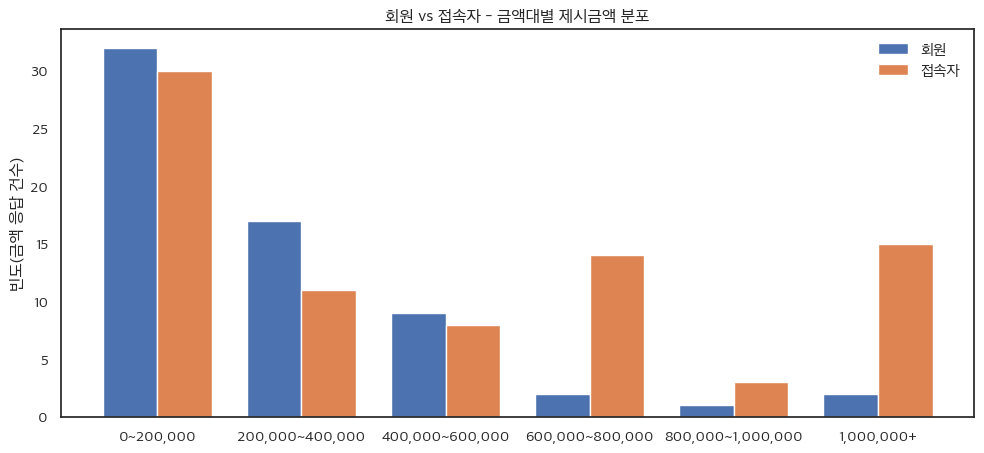

In [19]:
# 회원/접속자별 P4 전체 제시금액 분포 (막대 히스토그램)
# 구간: [0~200k), [200k~400k), [400k~600k), [600k~800k), [800k~1,000k), [1,000k+]
# 그래프 막대 높이 : 금액 응답 건수

# 저장 경로 설정
save_dir = Path(result_path) / "Output_Graphs"
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "1_Amount_dist_by_group.png"

# P4 계열 금액 컬럼 자동 탐지
p4_cols = [c for c in df.columns if str(c).startswith("P4-")]
if not p4_cols:
    raise ValueError("P4- 로 컬럼 없음 : 원자료 컬럼명 확인 필요")

# 응답자 식별용 ID (없으면 index를 사용)
if "respondent_id" not in df.columns:
    df = df.copy()
    df["respondent_id"] = df.index.astype(int)

# 금액 텍스트 → float(원)
def to_money(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True).str.replace(",", "")
    s = s.replace({"": np.nan, "-": np.nan, ".": np.nan, "-.": np.nan})
    return pd.to_numeric(s, errors="coerce")

# Info1 / 응답자ID / 금액만 추출해서 long형으로 변환
tmp = df[["respondent_id", "Info1"] + p4_cols].copy()
for c in p4_cols:
    tmp[c] = to_money(tmp[c])

long = tmp.melt(
    id_vars=["respondent_id", "Info1"],
    value_vars=p4_cols,
    var_name="항목",
    value_name="제시금액"
)

# 양수(>0)만 사용
long["제시금액"] = pd.to_numeric(long["제시금액"], errors="coerce")
long = long[long["제시금액"] > 0].copy()

# 그룹 라벨 표준화(회원/접속자)
def normalize_group(x: str) -> str:
    s = str(x).strip()
    if s in ["회원", "멤버", "member", "Member"]:
        return "회원"
    if s in ["접속자", "비회원", "visitor", "Visitor", "비 회원", "게스트"]:
        return "접속자"
    return s

long["그룹"] = long["Info1"].astype(str).map(normalize_group)

# 금액 구간 정의(원 단위)
bins = [0, 200_000, 400_000, 600_000, 800_000, 1_000_000, np.inf]
labels = [
    "0~200,000",
    "200,000~400,000",
    "400,000~600,000",
    "600,000~800,000",
    "800,000~1,000,000",
    "1,000,000+"
]
long["금액구간"] = pd.cut(long["제시금액"], bins=bins, labels=labels, right=False)

# 그룹 × 구간 교차집계 (빈도: 금액 응답 건수)
ct = (
    long
    .groupby(["그룹", "금액구간"])["제시금액"]
    .size()
    .unstack(0)             # 열: 그룹
    .reindex(labels)        # 금액 구간 순서 고정
    .fillna(0)
    .astype(int)
)

# 그룹 열 순서(회원, 접속자) 정리
cols_order = [c for c in ["회원", "접속자"] if c in ct.columns] or list(ct.columns)
ct = ct[cols_order]

# 막대 그래프 (회원/접속자 나란히)
plt.figure(figsize=(10, 4.7))
x = np.arange(len(ct.index))
bar_w = 0.38

for i, col in enumerate(ct.columns):
    plt.bar(
        x + i*bar_w - (bar_w*(len(ct.columns)-1)/2),
        ct[col].values,
        width=bar_w,
        label=col
    )

plt.xticks(x, ct.index, rotation=0)
plt.ylabel("빈도(금액 응답 건수)")
plt.title("회원 vs 접속자 - 금액대별 제시금액 분포")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

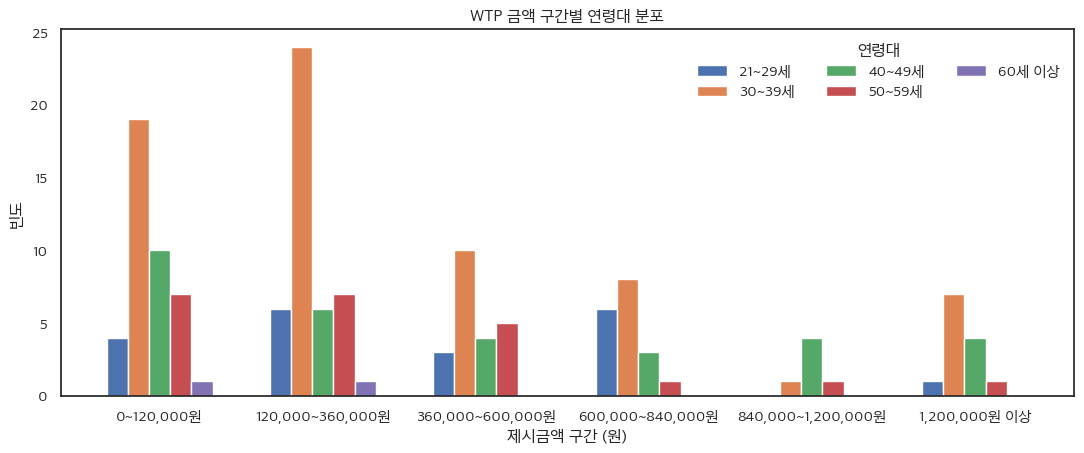

In [20]:
# 연령대별 P4 제시금액 분포 (막대 그래프)
# 금액 구간 기준 : 0~120,000원 / 120,000~360,000원 / 360,000~600,000원 / 600,000~840,000원 / 840,000~1,200,000원 / 1,200,000원 이상
# 연령 변수: P1-Q2

# 저장 경로 설정
save_dir = Path(result_path) / "Output_Graphs"
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "2_Age_vs_Amount_dist.png"

# P4 계열 금액 컬럼 찾기
p4_cols = [c for c in df.columns if str(c).startswith("P4-")]
if not p4_cols:
    raise ValueError("P4- 로 컬럼 없음 : 원자료 컬럼명 확인 필요")

# 금액 텍스트 -> 숫자(원)
def to_money(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True).str.replace(",", "")
    s = s.replace({"": np.nan, "-": np.nan, ".": np.nan, "-.": np.nan})
    return pd.to_numeric(s, errors="coerce")

# 필요한 변수만 추출 (연령 + 금액)
tmp = df[["P1-Q2"] + p4_cols].copy()
for c in p4_cols:
    tmp[c] = to_money(tmp[c])

# long 형태로 변환 (모든 P4 금액을 하나의 열로 모음)
long = tmp.melt(
    id_vars="P1-Q2",
    value_vars=p4_cols,
    var_name="항목",
    value_name="제시금액"
)

# 금액이 양수인 경우만 사용
long["제시금액"] = pd.to_numeric(long["제시금액"], errors="coerce")
long = long[long["제시금액"] > 0].copy()

# 연령대 정리
long["연령대"] = long["P1-Q2"].astype(str).str.strip()
long["연령대"] = long["연령대"].replace({
    "20대": "20대",
    "30대": "30대",
    "40대": "40대",
    "50대": "50대",
    "60대 이상": "60대 이상",
    "70대": "60대 이상",
    "미응답": "기타",
    "": np.nan
})
long = long[long["연령대"].notna()].copy()

# 금액 구간 나누기 (라벨은 그대로 원 단위 표기)
bins = [
    0,
    120_000,
    360_000,
    600_000,
    840_000,
    1_200_000,
    np.inf
]
labels = [
    "0~120,000원",
    "120,000~360,000원",
    "360,000~600,000원",
    "600,000~840,000원",
    "840,000~1,200,000원",
    "1,200,000원 이상"
]

long["금액구간"] = pd.cut(
    long["제시금액"],
    bins=bins,
    labels=labels,
    right=False
)

# 연령대 × 금액구간 교차집계 (빈도수)
ct = (
    long.groupby(["연령대", "금액구간"])["제시금액"]
        .size()
        .unstack(0)           # 열: 연령대
        .fillna(0)
        .astype(int)
        .reindex(labels)      # 금액구간 순서를 y축(또는 x축 라벨)에서 고정
)

# 막대 그래프 그리기 (연령대별로 막대 나란히)
plt.figure(figsize=(11, 4.7))
x = np.arange(len(ct.index))
bar_w = 0.13  # 막대 너비

for i, col in enumerate(ct.columns):
    plt.bar(
        x + i*bar_w - (bar_w*(len(ct.columns)-1)/2),
        ct[col].values,
        width=bar_w,
        label=col
    )

plt.xticks(x, ct.index, rotation=0)
plt.ylabel("빈도")
plt.xlabel("제시금액 구간 (원)")
plt.title("WTP 금액 구간별 연령대 분포")
plt.legend(title="연령대", frameon=False, ncol=3)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

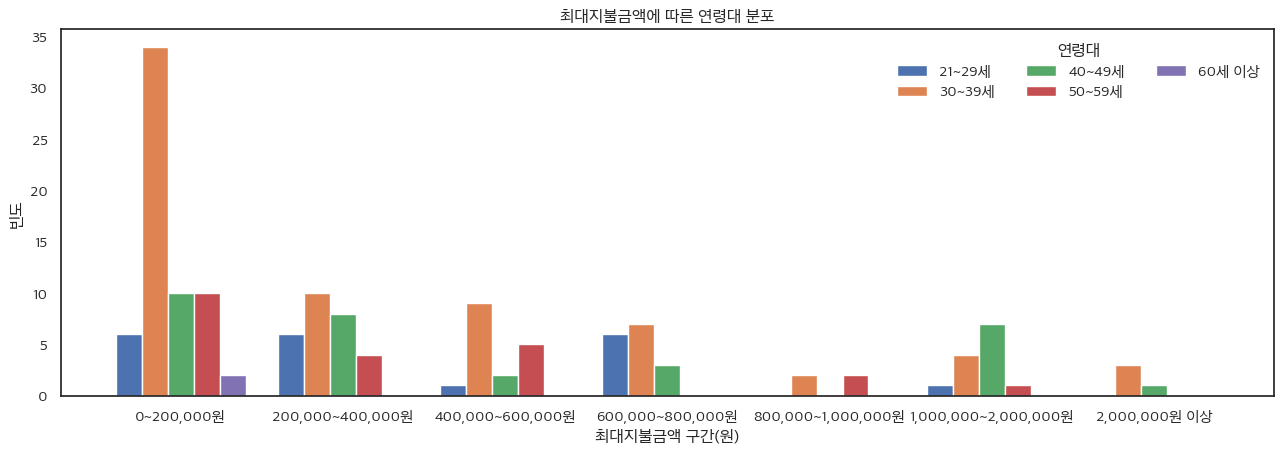

In [21]:
# 최대지불금액(최종 WTP) × 연령대 분포 막대그래프
# 최대지불금액: P4-Q3 / Q4 / Q6 / Q7
# 연령대: P1-Q2 ("21~29세", "30~39세", ...)
# 금액구간: 7구간 (0~200000 / ... / 2,000,000+)

# 사용 컬럼
AGE_COL = "P1-Q2"
Q1_COL, Q2_COL, Q3_COL = "P4-Q1", "P4-Q2", "P4-Q3"
Q4_COL, Q5_COL, Q6_COL, Q7_COL = "P4-Q4", "P4-Q5", "P4-Q6", "P4-Q7"

# 저장 경로 설정
out_dir = Path(result_path) / "Output_Graphs"
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / "3_MaxWTP_by_Age.png"

# 금액 문자열 -> 숫자 변환 함수
def to_money(series: pd.Series) -> pd.Series:
    s = series.astype(str)
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True).str.replace(",", "")
    s = s.replace({"": np.nan, "-": np.nan, ".": np.nan, "-.": np.nan})
    return pd.to_numeric(s, errors="coerce")

amt_Q3 = to_money(df[Q3_COL])
amt_Q4 = to_money(df[Q4_COL])
amt_Q6 = to_money(df[Q6_COL])
amt_Q7 = to_money(df[Q7_COL])

ans1 = df[Q1_COL].astype(str).str.strip()
ans2_yesbranch = df[Q2_COL].astype(str).str.strip()
ans2_nobranch = df[Q5_COL].astype(str).str.strip()

# 응답 규칙에 따른 최대지불금액 계산
max_wtp_list = []
for i in range(len(df)):
    a1 = ans1.iat[i]
    a2_yes = ans2_yesbranch.iat[i] if i < len(ans2_yesbranch) else np.nan
    a2_no  = ans2_nobranch.iat[i]  if i < len(ans2_nobranch)  else np.nan

    if a1 == "예":
        if a2_yes == "예": val = amt_Q3.iat[i]
        elif a2_yes == "아니오": val = amt_Q4.iat[i]
        else: val = np.nan
    elif a1 == "아니오":
        if a2_no == "예": val = amt_Q6.iat[i]
        elif a2_no == "아니오": val = amt_Q7.iat[i]
        else: val = np.nan
    else:
        val = np.nan
    max_wtp_list.append(val)

max_wtp = pd.to_numeric(pd.Series(max_wtp_list), errors="coerce")
max_wtp[(max_wtp <= 0) | (~np.isfinite(max_wtp))] = np.nan

# 연령대 처리
age_text = df[AGE_COL].astype(str).str.strip()
valid_age_labels = ["21~29세", "30~39세", "40~49세", "50~59세", "60세 이상"]
age_group = age_text.where(age_text.isin(valid_age_labels), np.nan)

# 금액 구간 정의
bins_amt = [0, 200_000, 400_000, 600_000, 800_000, 1_000_000, 2_000_000, np.inf]
labels_amt = [
    "0~200,000원",
    "200,000~400,000원",
    "400,000~600,000원",
    "600,000~800,000원",
    "800,000~1,000,000원",
    "1,000,000~2,000,000원",
    "2,000,000원 이상"
]

amt_bucket = pd.cut(max_wtp, bins=bins_amt, labels=labels_amt, right=False)

# 교차집계
plot_df = pd.DataFrame({"연령대": age_group, "금액구간": amt_bucket}).dropna()
ct = (
    plot_df.groupby(["금액구간", "연령대"])
    .size()
    .unstack("연령대")
    .reindex(labels_amt)
    .fillna(0)
    .astype(int)
    .reindex(columns=valid_age_labels)
)

# 그래프
plt.figure(figsize=(13, 4.7))
x = np.arange(len(ct.index))
num_groups = len(ct.columns)
bar_w = 0.8 / max(num_groups, 1)

for i, col in enumerate(ct.columns):
    plt.bar(
        x + (i - (num_groups-1)/2)*bar_w,
        ct[col].values,
        width=bar_w,
        label=col
    )

plt.xticks(x, ct.index, rotation=0)
plt.ylabel("빈도")
plt.xlabel("최대지불금액 구간(원)")
plt.title("최대지불금액에 따른 연령대 분포")
plt.legend(title="연령대", frameon=False, ncol=min(num_groups,3))
plt.tight_layout()
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()